Array: [4, 5, 12, 15, 23, 65, 98, 100, 175, 190, 205, 220]
Searching for: 175
Found at index: 8, Comparisons: 1

      Size    IS Time(ms)    BS Time(ms)   IS Comparisons   BS Comparisons
---------------------------------------------------------------------------
      1000         0.0054         0.0053                4               10
      5000         0.0089         0.0071                4               11
     10000         0.0076         0.0155                4               12
     50000         0.0175         0.0066                8               16
    100000         0.0037         0.0090                4               17


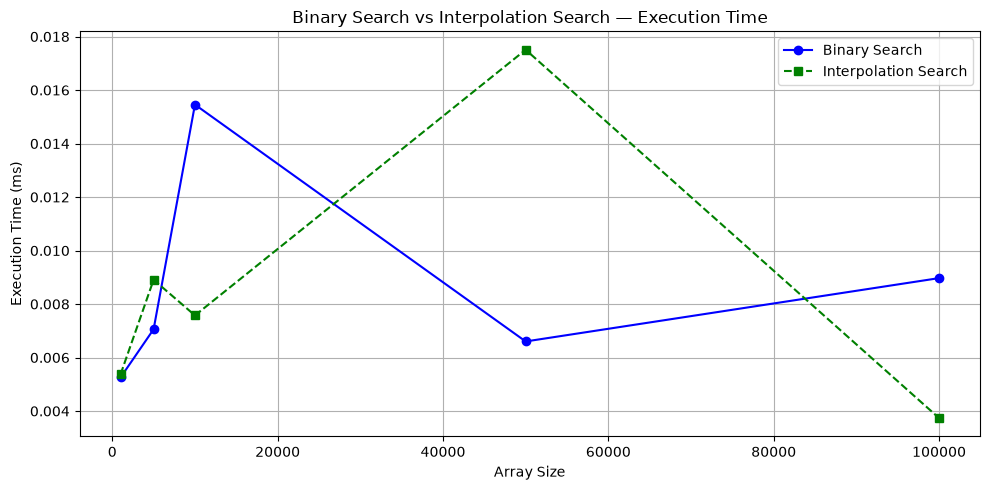

In [2]:
import random
import time
import matplotlib.pyplot as plt


def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0

    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            if arr[low] == target:
                return low, comparisons
            return -1, comparisons

        # Interpolation formula
        pos = low + int(((target - arr[low]) * (high - low))
                        / (arr[high] - arr[low]))

        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, comparisons


def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons


def performance_analysis():
    sizes = [1000, 5000, 10000, 50000, 100000]

    is_times = []
    bs_times = []

    print(f"{'Size':>10} {'IS Time(ms)':>14} {'BS Time(ms)':>14} "
          f"{'IS Comparisons':>16} {'BS Comparisons':>16}")
    print('-' * 75)

    for size in sizes:
        arr = sorted(random.sample(range(size * 10), size))
        target = arr[random.randint(0, size - 1)]

        # Interpolation Search timing
        start = time.perf_counter()
        for _ in range(100):
            idx_is, comp_is = interpolation_search(arr, target)
        is_time = (time.perf_counter() - start) / 100 * 1000

        # Binary Search timing
        start = time.perf_counter()
        for _ in range(100):
            idx_bs, comp_bs = binary_search(arr, target)
        bs_time = (time.perf_counter() - start) / 100 * 1000

        is_times.append(is_time)
        bs_times.append(bs_time)

        print(f"{size:>10} {is_time:>14.4f} {bs_time:>14.4f} "
              f"{comp_is:>16} {comp_bs:>16}")

    plt.figure(figsize=(10, 5))

    plt.plot(sizes, bs_times, marker='o', label='Binary Search',
             color='blue')
    plt.plot(sizes, is_times, marker='s', label='Interpolation Search',
             color='green', linestyle='--')

    plt.xlabel("Array Size")
    plt.ylabel("Execution Time (ms)")
    plt.title("Binary Search vs Interpolation Search — Execution Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("search_comparison.png")
    plt.show()


# --- Main ---
arr = [4, 5, 12, 15, 23, 65, 98, 100, 175, 190, 205, 220]
target = 175
idx, comps = interpolation_search(arr, target)
print(f"Array: {arr}")
print(f"Searching for: {target}")
print(f"Found at index: {idx}, Comparisons: {comps}")
print()
performance_analysis()